In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

In [5]:
usuarios_activos = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_actualizado.csv')
usuarios_eliminados = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_actualizado.csv')

In [ ]:
usuarios_activos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29522 entries, 0 to 29521
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       29522 non-null  int64  
 1   amount                                   29522 non-null  float64
 2   status                                   29522 non-null  object 
 3   created_at                               29522 non-null  object 
 4   updated_at                               29522 non-null  object 
 5   user_id                                  29522 non-null  float64
 6   moderated_at                             19434 non-null  object 
 7   reimbursement_date                       29522 non-null  object 
 8   cash_request_received_date               22988 non-null  object 
 9   money_back_date                          22750 non-null  object 
 10  transfer_type                            29522

In [ ]:
usuarios_eliminados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2573 entries, 0 to 2572
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       2573 non-null   int64  
 1   amount                                   2573 non-null   float64
 2   status                                   2573 non-null   object 
 3   created_at                               2573 non-null   object 
 4   updated_at                               2573 non-null   object 
 5   moderated_at                             2326 non-null   object 
 6   deleted_account_id                       2573 non-null   float64
 7   reimbursement_date                       2573 non-null   object 
 8   cash_request_received_date               1162 non-null   object 
 9   money_back_date                          1168 non-null   object 
 10  transfer_type                            2573 no

In [ ]:
usuarios_activos["created_at"].min()

'2019-11-19 13:57:53.511561+00:00'

In [6]:
import pandas as pd

# Lista de columnas de fechas en los datasets
columnas_fechas = [
    "created_at", "updated_at", "paid_at", "from_date", "to_date",
    "created_at_fees", "updated_at_fees", "paid_at_fees",
    "cash_request_created_at", "cash_request_updated_at",
    "reimbursement_date", "cash_request_received_date",
    "money_back_date", "send_at", "moderated_at"
]

# Función para convertir fechas eliminando la zona horaria
def convertir_fechas_sin_zona_horaria(df, columnas_fechas):
    for col in columnas_fechas:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce").dt.tz_localize(None)
    return df

# Aplicar la conversión a ambos datasets
usuarios_activos = convertir_fechas_sin_zona_horaria(usuarios_activos, columnas_fechas)
usuarios_eliminados = convertir_fechas_sin_zona_horaria(usuarios_eliminados, columnas_fechas)




In [7]:
usuarios_activos["cohorte_primer_solicitud"] = usuarios_activos.groupby("user_id")["created_at"].transform("min").dt.to_period("M")
usuarios_eliminados["cohorte_primer_solicitud"] = usuarios_eliminados.groupby("deleted_account_id")["created_at"].transform("min").dt.to_period("M")

<ipython-input-8-21590a26855c>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=solicitudes_mes_activos.index.astype(str), y=solicitudes_mes_activos.values, palette="Blues")


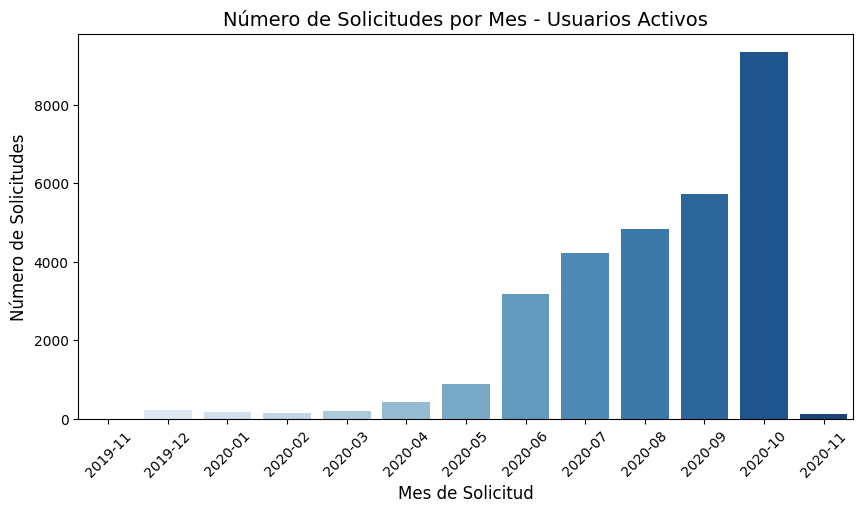

<ipython-input-8-21590a26855c>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=solicitudes_mes_eliminados.index.astype(str), y=solicitudes_mes_eliminados.values, palette="Reds")


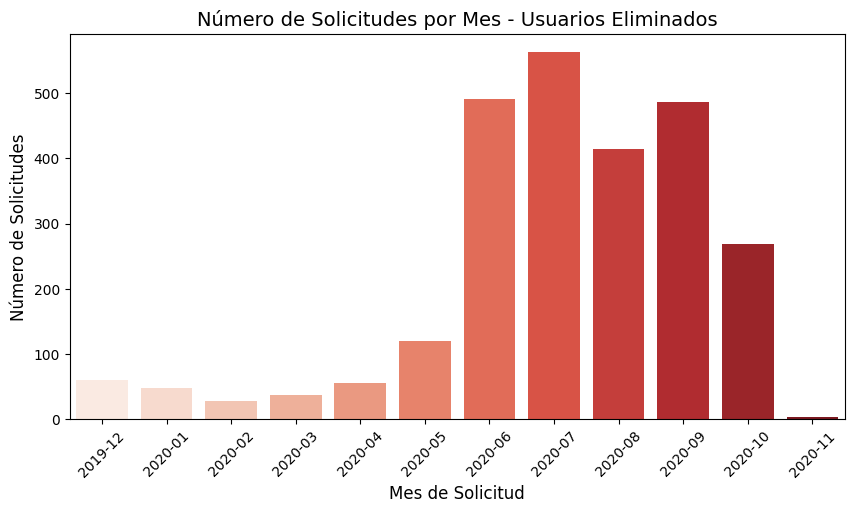

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Análisis de solicitudes por mes en Usuarios Activos
solicitudes_mes_activos = usuarios_activos["mes_solicitud"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=solicitudes_mes_activos.index.astype(str), y=solicitudes_mes_activos.values, palette="Blues")
plt.xlabel("Mes de Solicitud", fontsize=12)
plt.ylabel("Número de Solicitudes", fontsize=12)
plt.title("Número de Solicitudes por Mes - Usuarios Activos", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# 🔹 Análisis de solicitudes por mes en Usuarios Eliminados
solicitudes_mes_eliminados = usuarios_eliminados["mes_solicitud"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=solicitudes_mes_eliminados.index.astype(str), y=solicitudes_mes_eliminados.values, palette="Reds")
plt.xlabel("Mes de Solicitud", fontsize=12)
plt.ylabel("Número de Solicitudes", fontsize=12)
plt.title("Número de Solicitudes por Mes - Usuarios Eliminados", fontsize=14)
plt.xticks(rotation=45)
plt.show()


<ipython-input-43-c76ede53b933>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=solicitudes_octubre_2020.index, y=solicitudes_octubre_2020.values, palette="Blues")


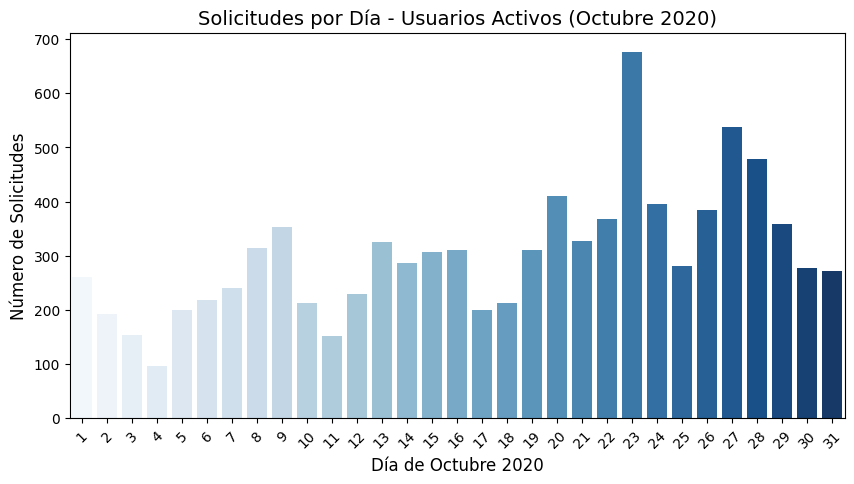

<ipython-input-43-c76ede53b933>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=solicitudes_julio_2020.index, y=solicitudes_julio_2020.values, palette="Reds")


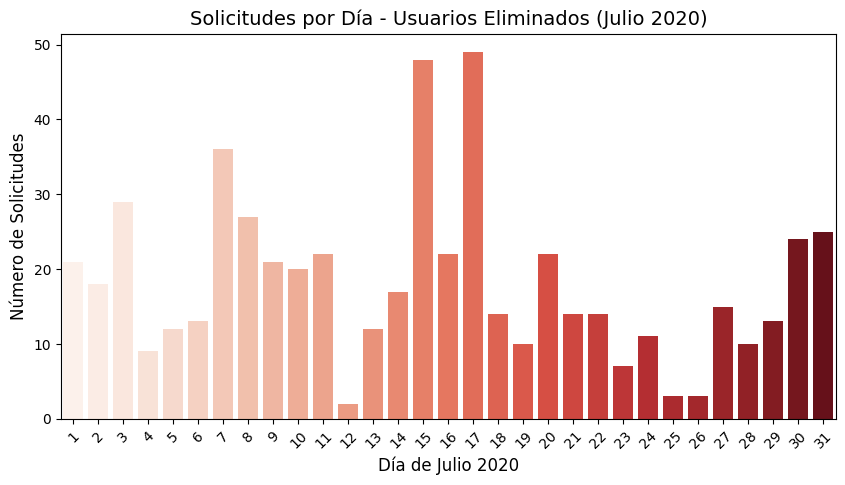

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Filtrar Usuarios Activos en Octubre 2020
activos_octubre_2020 = usuarios_activos[usuarios_activos["mes_solicitud"] == "2020-10"]

# Contar solicitudes por día dentro de Octubre 2020
solicitudes_octubre_2020 = activos_octubre_2020["created_at"].dt.day.value_counts().sort_index()

# Graficar
plt.figure(figsize=(10, 5))
sns.barplot(x=solicitudes_octubre_2020.index, y=solicitudes_octubre_2020.values, palette="Blues")
plt.xlabel("Día de Octubre 2020", fontsize=12)
plt.ylabel("Número de Solicitudes", fontsize=12)
plt.title("Solicitudes por Día - Usuarios Activos (Octubre 2020)", fontsize=14)
plt.xticks(rotation=45)
plt.show()


# 🔹 Filtrar Usuarios Eliminados en Julio 2020
eliminados_julio_2020 = usuarios_eliminados[usuarios_eliminados["mes_solicitud"] == "2020-07"]

# Contar solicitudes por día dentro de Julio 2020
solicitudes_julio_2020 = eliminados_julio_2020["created_at"].dt.day.value_counts().sort_index()

# Graficar
plt.figure(figsize=(10, 5))
sns.barplot(x=solicitudes_julio_2020.index, y=solicitudes_julio_2020.values, palette="Reds")
plt.xlabel("Día de Julio 2020", fontsize=12)
plt.ylabel("Número de Solicitudes", fontsize=12)
plt.title("Solicitudes por Día - Usuarios Eliminados (Julio 2020)", fontsize=14)
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Verificar los primeros valores de la columna "hora_solicitud"
print("Primeros valores de 'hora_solicitud' en usuarios_activos:")
print(usuarios_activos["hora_solicitud"].head(10))

print("\nPrimeros valores de 'hora_solicitud' en usuarios_eliminados:")
print(usuarios_eliminados["hora_solicitud"].head(10))

# Verificar el tipo de datos
print("\nTipo de datos de 'hora_solicitud' en usuarios_activos:", usuarios_activos["hora_solicitud"].dtype)
print("Tipo de datos de 'hora_solicitud' en usuarios_eliminados:", usuarios_eliminados["hora_solicitud"].dtype)


Primeros valores de 'hora_solicitud' en usuarios_activos:
0    19_Tuesday_50_December_2019
1    19_Tuesday_50_December_2019
2    19_Tuesday_50_December_2019
3    19_Tuesday_50_December_2019
4        9_Wednesday_19_May_2020
5        20_Saturday_21_May_2020
6        17_Tuesday_25_June_2020
7    19_Tuesday_50_December_2019
8    19_Saturday_6_February_2020
9        21_Thursday_20_May_2020
Name: hora_solicitud, dtype: object

Primeros valores de 'hora_solicitud' en usuarios_eliminados:
0        1_Monday_7_February_2020
1          12_Sunday_26_June_2020
2     13_Wednesday_5_January_2020
3    17_Wednesday_6_February_2020
4    7_Wednesday_50_December_2019
5       16_Thursday_12_March_2020
6          9_Monday_11_March_2020
7    17_Thursday_50_December_2019
8    18_Thursday_50_December_2019
9      15_Wednesday_18_April_2020
Name: hora_solicitud, dtype: object

Tipo de datos de 'hora_solicitud' en usuarios_activos: object
Tipo de datos de 'hora_solicitud' en usuarios_eliminados: object


In [11]:
# Función para extraer la primera parte de la cadena (que parece ser la hora)
def extraer_hora_v2(texto):
    if isinstance(texto, str):
        partes = texto.split("_")  # Dividir por "_"
        if partes[0].isdigit():  # Verificar si el primer elemento es un número
            hora = int(partes[0])
            if 0 <= hora < 24:  # Validar que esté en el rango correcto
                return hora
    return None  # Si no se puede extraer, devolver None

# Aplicar la función a la columna "hora_solicitud"
usuarios_activos["hora_solicitud"] = usuarios_activos["hora_solicitud"].apply(extraer_hora_v2)
usuarios_eliminados["hora_solicitud"] = usuarios_eliminados["hora_solicitud"].apply(extraer_hora_v2)

# Verificar la conversión
print("\nPrimeros valores corregidos de 'hora_solicitud' en usuarios_activos:")
print(usuarios_activos["hora_solicitud"].head(10))

print("\nPrimeros valores corregidos de 'hora_solicitud' en usuarios_eliminados:")
print(usuarios_eliminados["hora_solicitud"].head(10))



Primeros valores corregidos de 'hora_solicitud' en usuarios_activos:
0    19
1    19
2    19
3    19
4     9
5    20
6    17
7    19
8    19
9    21
Name: hora_solicitud, dtype: int64

Primeros valores corregidos de 'hora_solicitud' en usuarios_eliminados:
0     1
1    12
2    13
3    17
4     7
5    16
6     9
7    17
8    18
9    15
Name: hora_solicitud, dtype: int64


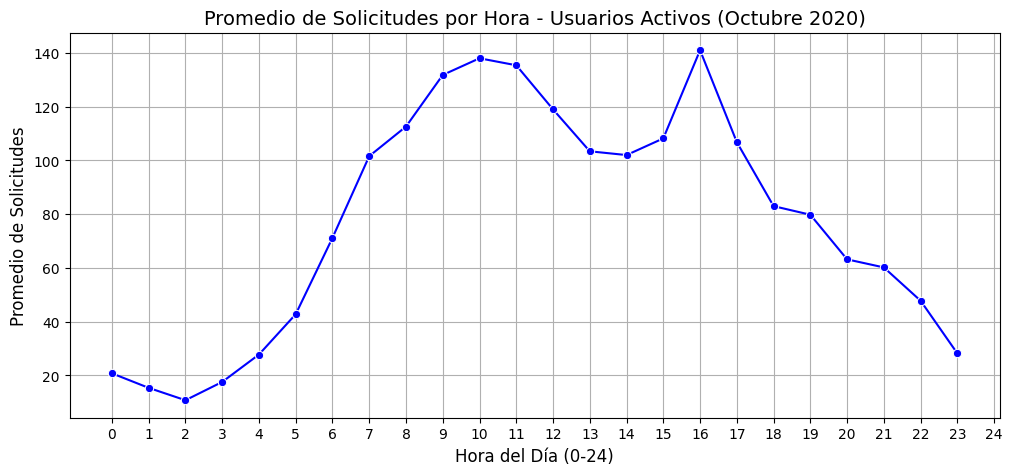

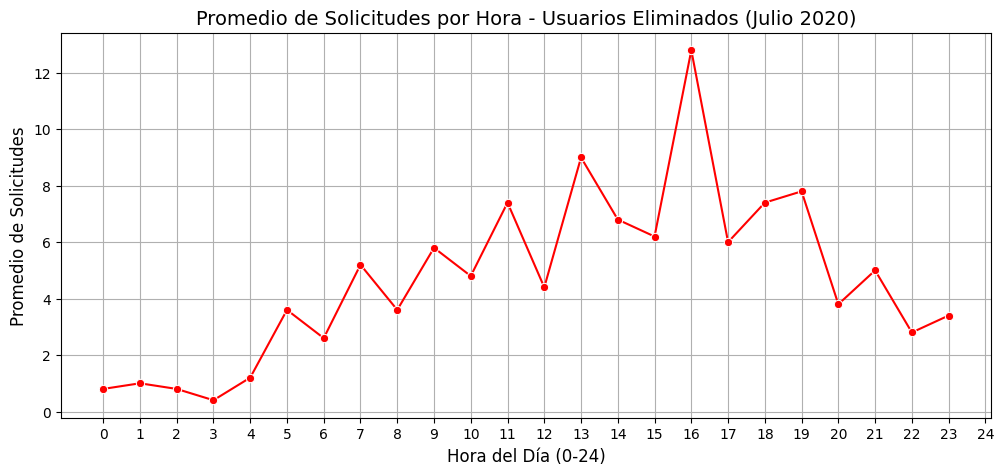

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 🔹 Filtrar Usuarios Activos en Octubre 2020
activos_octubre_2020 = usuarios_activos[usuarios_activos["mes_solicitud"] == "2020-10"]

# Calcular el promedio de solicitudes por hora en Octubre 2020
promedio_hora_activos = activos_octubre_2020.groupby("hora_solicitud").size() / activos_octubre_2020["semana_solicitud"].nunique()

# Graficar
plt.figure(figsize=(12, 5))
sns.lineplot(x=promedio_hora_activos.index, y=promedio_hora_activos.values, marker="o", color="b")
plt.xlabel("Hora del Día (0-24)", fontsize=12)
plt.ylabel("Promedio de Solicitudes", fontsize=12)
plt.title("Promedio de Solicitudes por Hora - Usuarios Activos (Octubre 2020)", fontsize=14)
plt.xticks(np.arange(0, 25, 1))
plt.grid()
plt.show()


# 🔹 Filtrar Usuarios Eliminados en Julio 2020
eliminados_julio_2020 = usuarios_eliminados[usuarios_eliminados["mes_solicitud"] == "2020-07"]

# Calcular el promedio de solicitudes por hora en Julio 2020
promedio_hora_eliminados = eliminados_julio_2020.groupby("hora_solicitud").size() / eliminados_julio_2020["semana_solicitud"].nunique()

# Graficar
plt.figure(figsize=(12, 5))
sns.lineplot(x=promedio_hora_eliminados.index, y=promedio_hora_eliminados.values, marker="o", color="r")
plt.xlabel("Hora del Día (0-24)", fontsize=12)
plt.ylabel("Promedio de Solicitudes", fontsize=12)
plt.title("Promedio de Solicitudes por Hora - Usuarios Eliminados (Julio 2020)", fontsize=14)
plt.xticks(np.arange(0, 25, 1))
plt.grid()
plt.show()


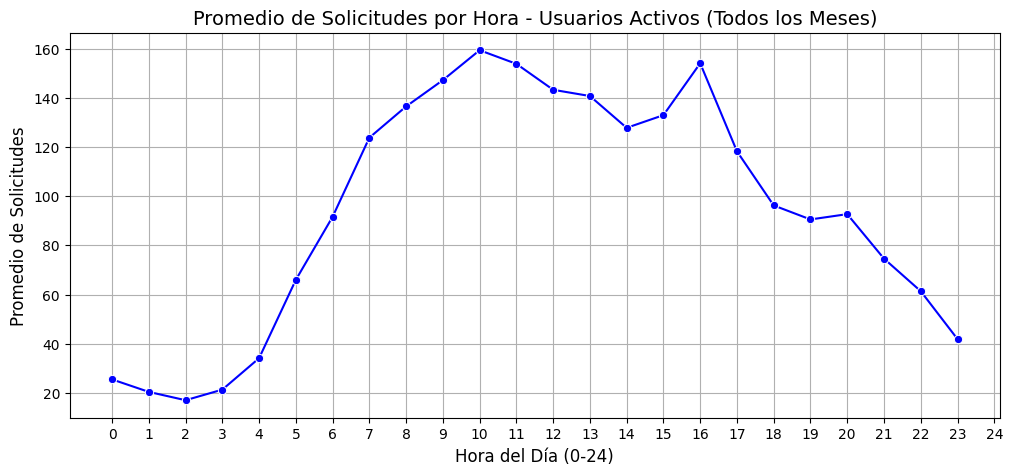

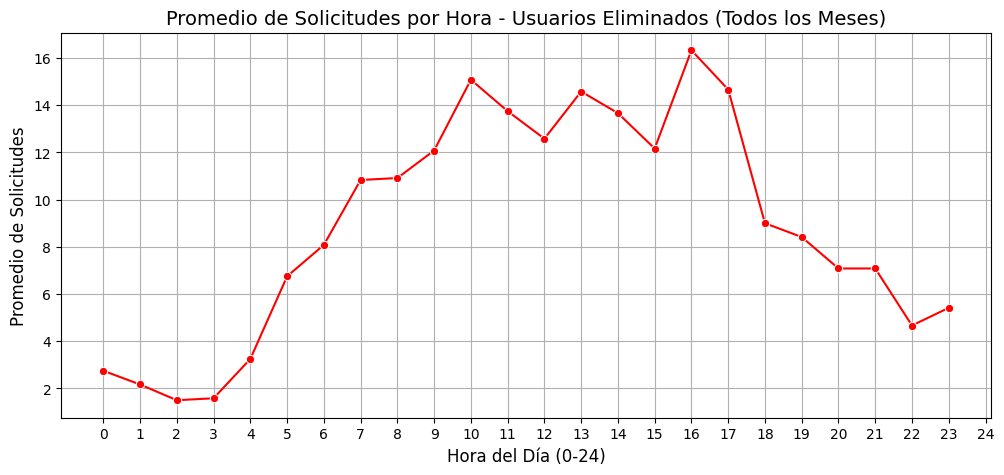

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 🔹 Calcular el promedio de solicitudes por hora en TODOS los meses para Usuarios Activos
promedio_hora_activos = usuarios_activos.groupby("hora_solicitud").size() / usuarios_activos["mes_solicitud"].nunique()

# Graficar
plt.figure(figsize=(12, 5))
sns.lineplot(x=promedio_hora_activos.index, y=promedio_hora_activos.values, marker="o", color="b")
plt.xlabel("Hora del Día (0-24)", fontsize=12)
plt.ylabel("Promedio de Solicitudes", fontsize=12)
plt.title("Promedio de Solicitudes por Hora - Usuarios Activos (Todos los Meses)", fontsize=14)
plt.xticks(np.arange(0, 25, 1))
plt.grid()
plt.show()


# 🔹 Calcular el promedio de solicitudes por hora en TODOS los meses para Usuarios Eliminados
promedio_hora_eliminados = usuarios_eliminados.groupby("hora_solicitud").size() / usuarios_eliminados["mes_solicitud"].nunique()

# Graficar
plt.figure(figsize=(12, 5))
sns.lineplot(x=promedio_hora_eliminados.index, y=promedio_hora_eliminados.values, marker="o", color="r")
plt.xlabel("Hora del Día (0-24)", fontsize=12)
plt.ylabel("Promedio de Solicitudes", fontsize=12)
plt.title("Promedio de Solicitudes por Hora - Usuarios Eliminados (Todos los Meses)", fontsize=14)
plt.xticks(np.arange(0, 25, 1))
plt.grid()
plt.show()


<ipython-input-12-cef084846f20>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cohort_counts.index.astype(str), y=cohort_counts.values, palette=color)


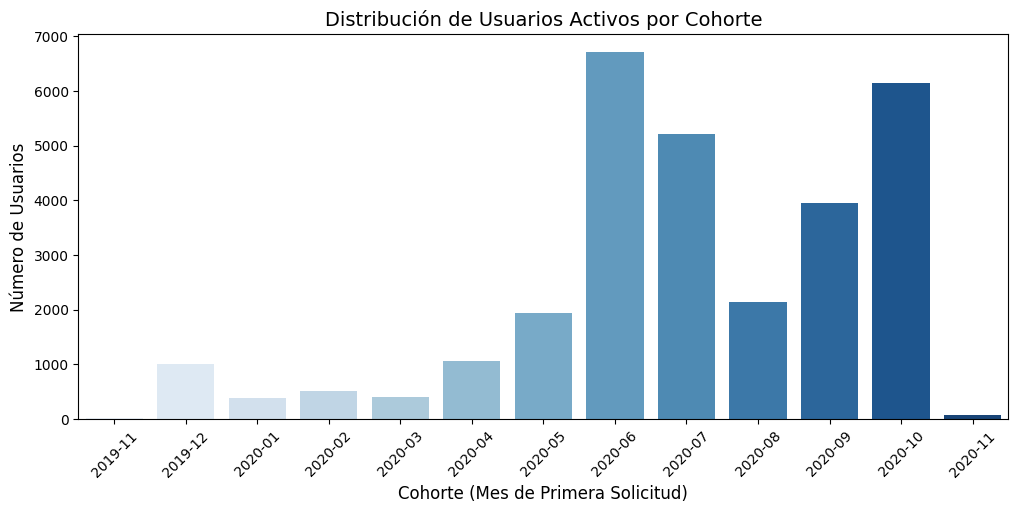

<ipython-input-12-cef084846f20>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cohort_counts.index.astype(str), y=cohort_counts.values, palette=color)


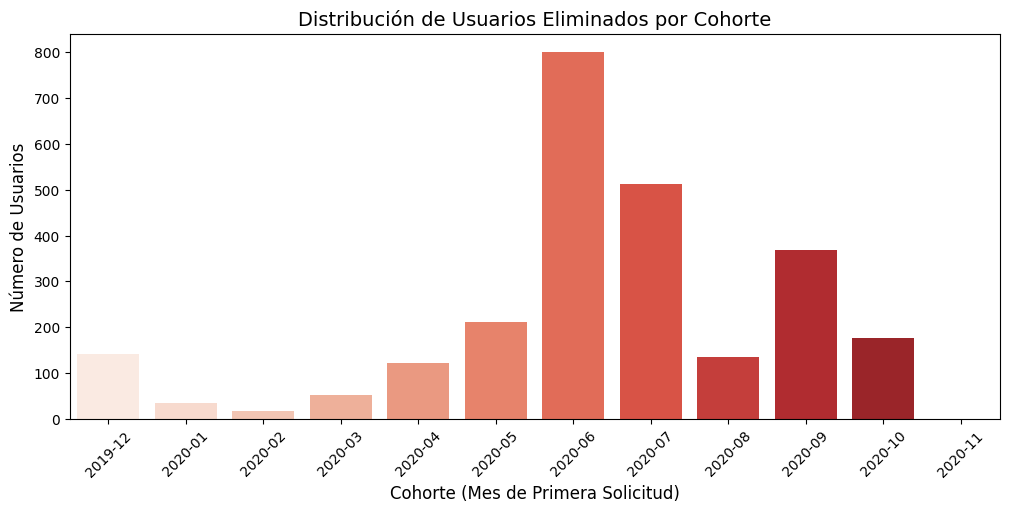

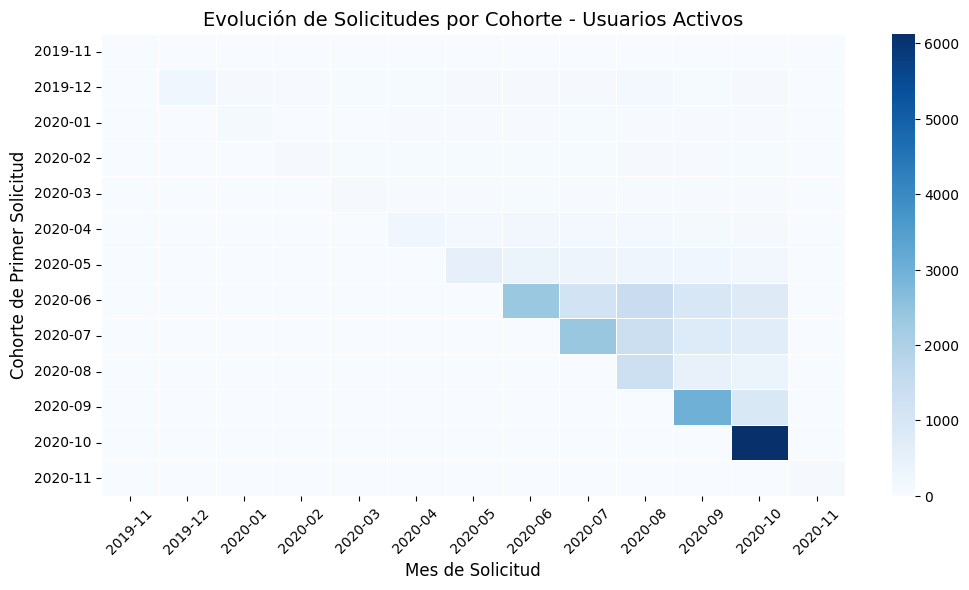

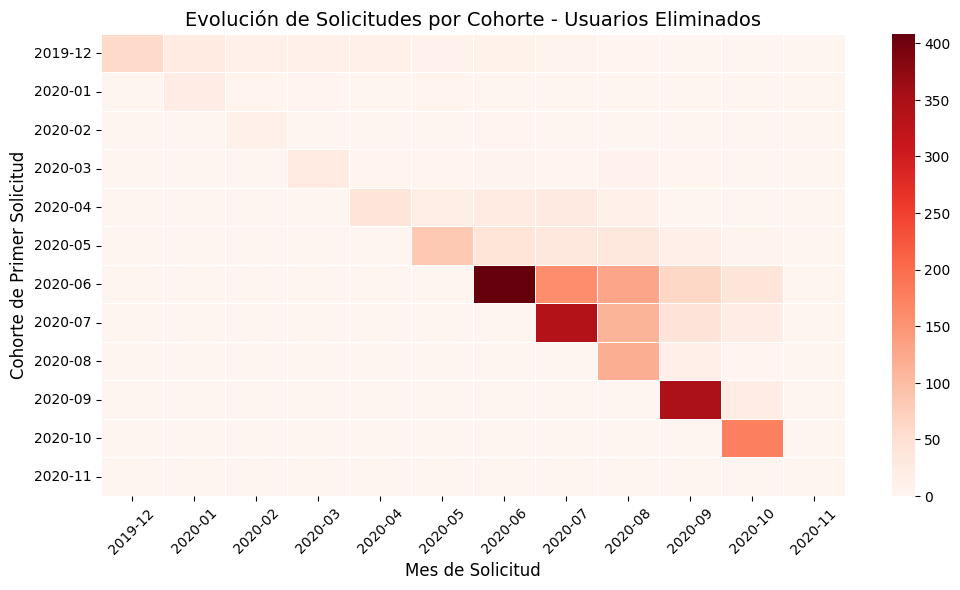

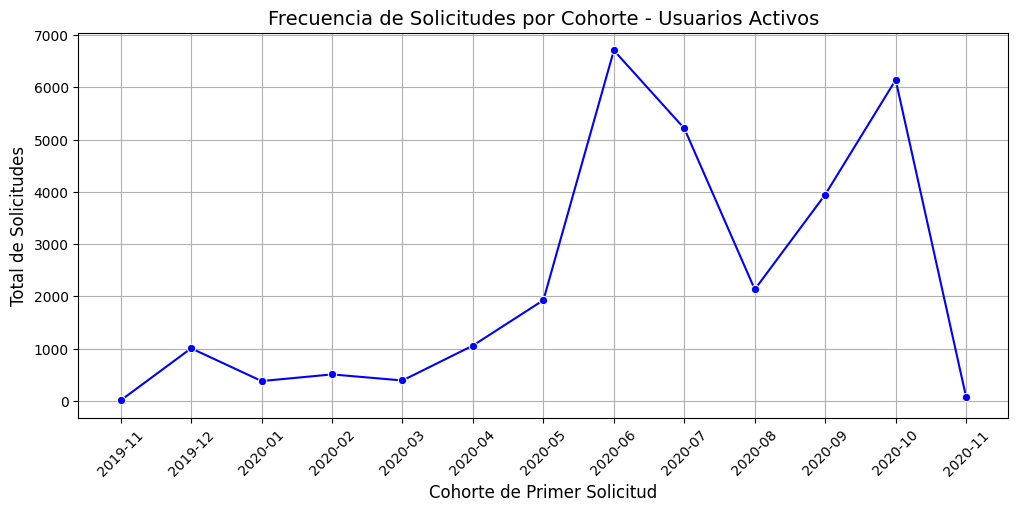

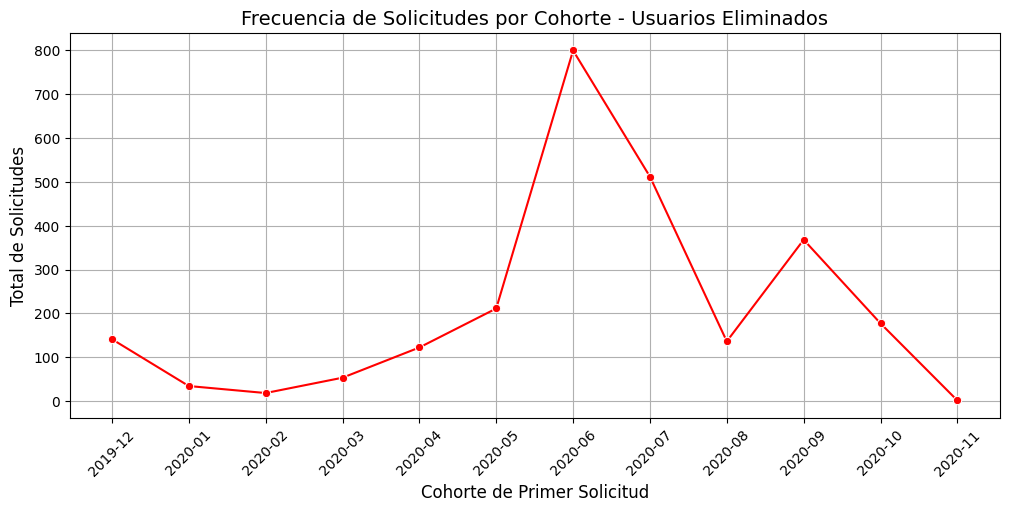

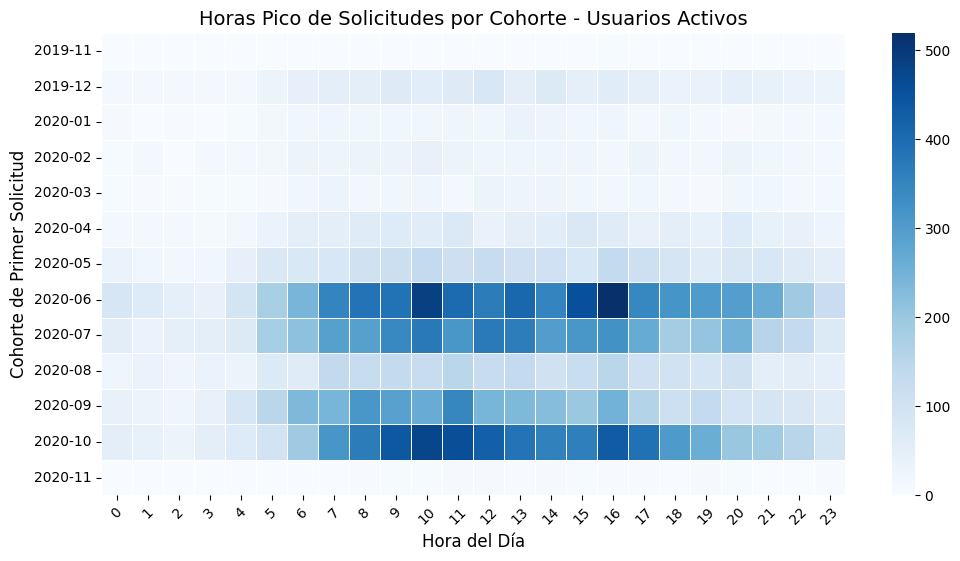

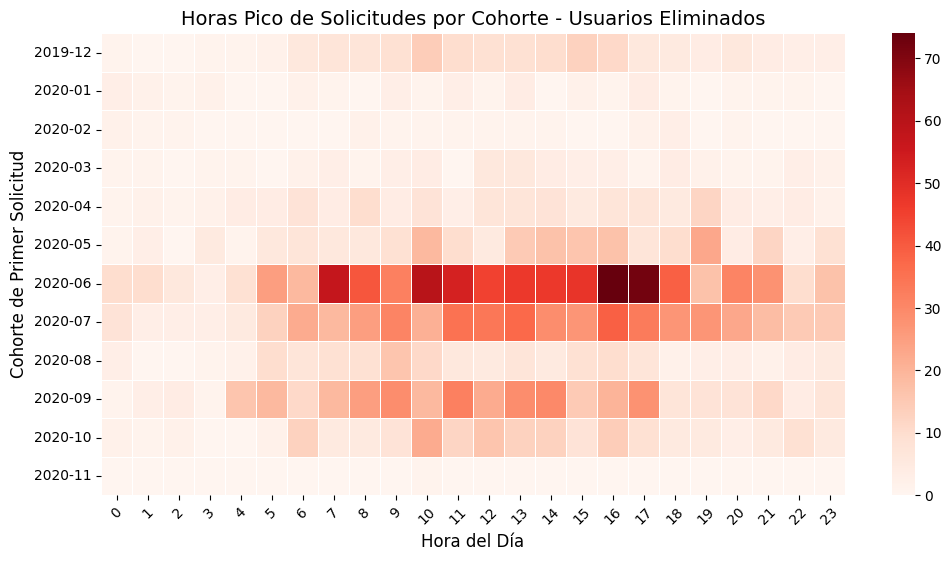

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Función para graficar la cantidad de usuarios por cohorte
def graficar_usuarios_por_cohorte(df, titulo, color):
    cohort_counts = df["cohorte_primer_solicitud"].value_counts().sort_index()

    plt.figure(figsize=(12, 5))
    sns.barplot(x=cohort_counts.index.astype(str), y=cohort_counts.values, palette=color)
    plt.xlabel("Cohorte (Mes de Primera Solicitud)", fontsize=12)
    plt.ylabel("Número de Usuarios", fontsize=12)
    plt.title(titulo, fontsize=14)
    plt.xticks(rotation=45)
    plt.show()


# 🔹 1. Distribución de Usuarios por Cohorte
graficar_usuarios_por_cohorte(usuarios_activos, "Distribución de Usuarios Activos por Cohorte", "Blues")
graficar_usuarios_por_cohorte(usuarios_eliminados, "Distribución de Usuarios Eliminados por Cohorte", "Reds")


# 🔹 2. Evolución de Solicitudes por Cohorte
def graficar_solicitudes_por_cohorte(df, titulo, color):
    cohort_solicitudes = df.groupby(["cohorte_primer_solicitud", "mes_solicitud"]).size().unstack().fillna(0)

    plt.figure(figsize=(12, 6))
    sns.heatmap(cohort_solicitudes, cmap=color, linewidths=0.5, annot=False)
    plt.xlabel("Mes de Solicitud", fontsize=12)
    plt.ylabel("Cohorte de Primer Solicitud", fontsize=12)
    plt.title(titulo, fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

graficar_solicitudes_por_cohorte(usuarios_activos, "Evolución de Solicitudes por Cohorte - Usuarios Activos", "Blues")
graficar_solicitudes_por_cohorte(usuarios_eliminados, "Evolución de Solicitudes por Cohorte - Usuarios Eliminados", "Reds")


# 🔹 3. Frecuencia de Solicitudes por Cohorte
def graficar_frecuencia_solicitudes(df, titulo, color, id_col):
    cohort_frecuencia = df.groupby("cohorte_primer_solicitud")[id_col].count().reset_index()
    cohort_frecuencia.columns = ["Cohorte", "Total_Solicitudes"]

    plt.figure(figsize=(12, 5))
    sns.lineplot(x=cohort_frecuencia["Cohorte"].astype(str), y=cohort_frecuencia["Total_Solicitudes"], marker="o", color=color)
    plt.xlabel("Cohorte de Primer Solicitud", fontsize=12)
    plt.ylabel("Total de Solicitudes", fontsize=12)
    plt.title(titulo, fontsize=14)
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

graficar_frecuencia_solicitudes(usuarios_activos, "Frecuencia de Solicitudes por Cohorte - Usuarios Activos", "b", "user_id")
graficar_frecuencia_solicitudes(usuarios_eliminados, "Frecuencia de Solicitudes por Cohorte - Usuarios Eliminados", "r", "deleted_account_id")


# 🔹 4. Análisis de Horas Pico por Cohorte
def graficar_horas_pico(df, titulo, color):
    horas_pico = df.groupby(["cohorte_primer_solicitud", "hora_solicitud"]).size().unstack().fillna(0)

    plt.figure(figsize=(12, 6))
    sns.heatmap(horas_pico, cmap=color, linewidths=0.5, annot=False)
    plt.xlabel("Hora del Día", fontsize=12)
    plt.ylabel("Cohorte de Primer Solicitud", fontsize=12)
    plt.title(titulo, fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

graficar_horas_pico(usuarios_activos, "Horas Pico de Solicitudes por Cohorte - Usuarios Activos", "Blues")
graficar_horas_pico(usuarios_eliminados, "Horas Pico de Solicitudes por Cohorte - Usuarios Eliminados", "Reds")


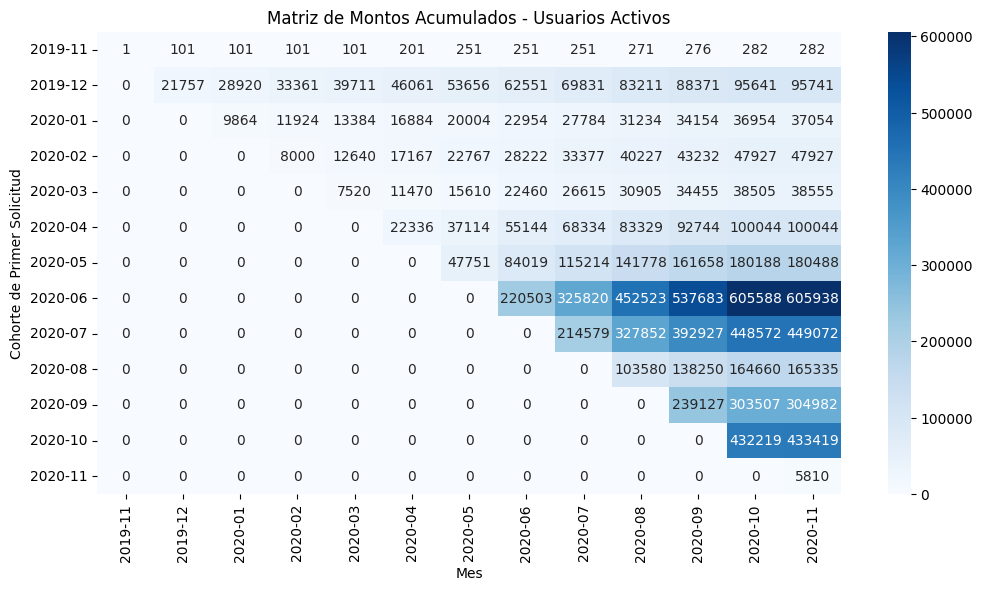

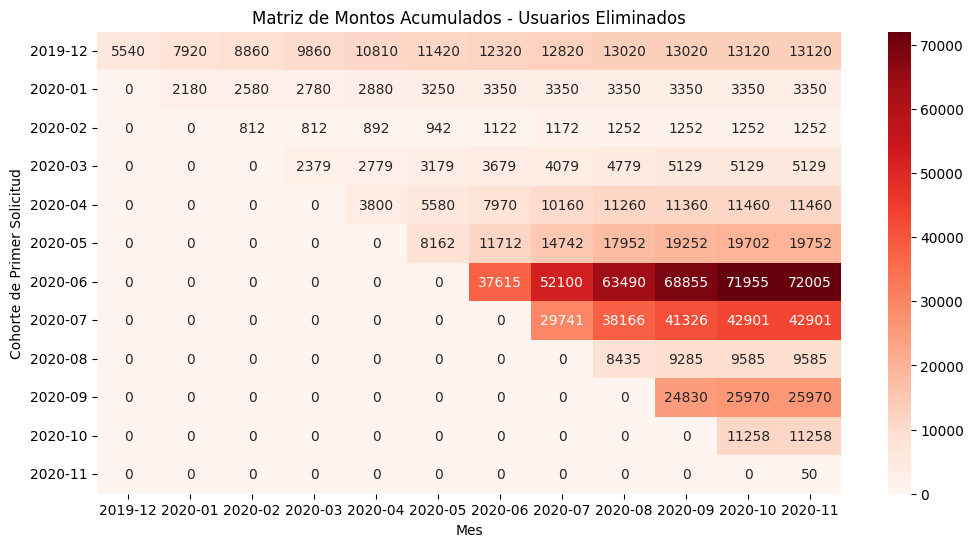

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Convertir la columna de fecha a datetime
usuarios_activos["created_at"] = pd.to_datetime(usuarios_activos["created_at"], errors="coerce")
usuarios_eliminados["created_at"] = pd.to_datetime(usuarios_eliminados["created_at"], errors="coerce")

# Asegurar que la columna de Mes esté en formato período (Año-Mes)
usuarios_activos["Mes"] = usuarios_activos["created_at"].dt.to_period("M")
usuarios_eliminados["Mes"] = usuarios_eliminados["created_at"].dt.to_period("M")

# Crear la matriz de montos acumulados por cohorte y mes (Usuarios Activos)
cohorte_matriz_activos = usuarios_activos.pivot_table(
    index="cohorte_primer_solicitud",
    columns="Mes",
    values="amount",
    aggfunc="sum",
    fill_value=0
).cumsum(axis=1)

# Crear la matriz de montos acumulados por cohorte y mes (Usuarios Eliminados)
cohorte_matriz_eliminados = usuarios_eliminados.pivot_table(
    index="cohorte_primer_solicitud",
    columns="Mes",
    values="amount",
    aggfunc="sum",
    fill_value=0
).cumsum(axis=1)

# Visualización de la matriz de cohorte (Usuarios Activos)
plt.figure(figsize=(12, 6))
sns.heatmap(cohorte_matriz_activos, cmap="Blues", annot=True, fmt=".0f")
plt.title("Matriz de Montos Acumulados - Usuarios Activos")
plt.xlabel("Mes")
plt.ylabel("Cohorte de Primer Solicitud")
plt.show()

# Visualización de la matriz de cohorte (Usuarios Eliminados)
plt.figure(figsize=(12, 6))
sns.heatmap(cohorte_matriz_eliminados, cmap="Reds", annot=True, fmt=".0f")
plt.title("Matriz de Montos Acumulados - Usuarios Eliminados")
plt.xlabel("Mes")
plt.ylabel("Cohorte de Primer Solicitud")
plt.show()



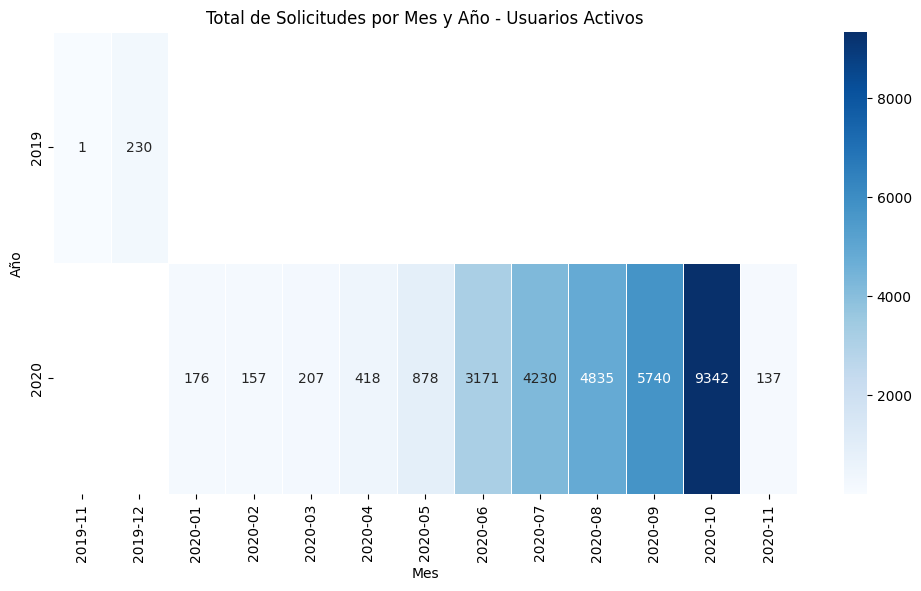

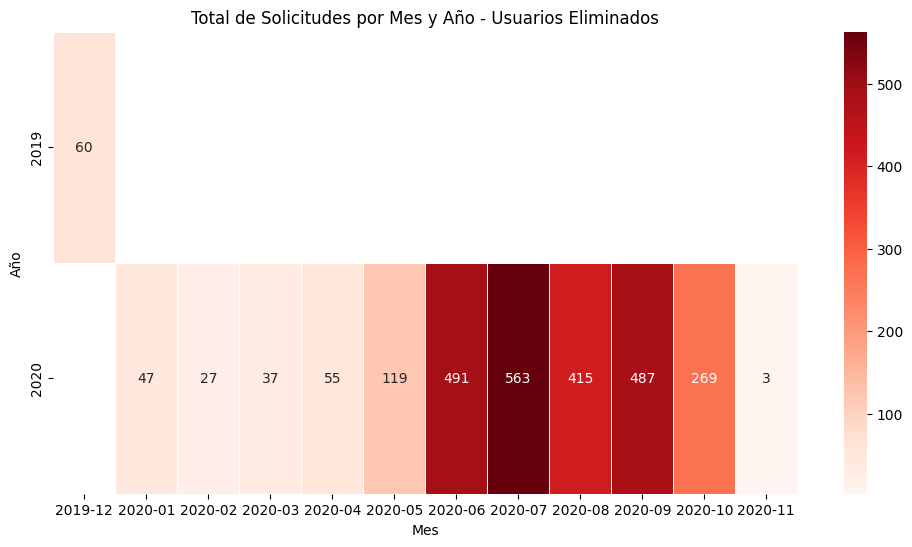

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una tabla de conteo de solicitudes por mes y año en usuarios activos
solicitudes_por_mes_activos = usuarios_activos.groupby(
    [usuarios_activos["created_at"].dt.year, "mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes por mes y año en usuarios eliminados
solicitudes_por_mes_eliminados = usuarios_eliminados.groupby(
    [usuarios_eliminados["created_at"].dt.year, "mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Matriz de calor para usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_mes_activos, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)
plt.title("Total de Solicitudes por Mes y Año - Usuarios Activos")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# Matriz de calor para usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_mes_eliminados, annot=True, fmt=".0f", cmap="Reds", linewidths=0.5)
plt.title("Total de Solicitudes por Mes y Año - Usuarios Eliminados")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()


In [ ]:
# Crear una tabla de conteo de solicitudes canceladas por mes y año en usuarios activos
canceladas_por_mes_activos = usuarios_activos[usuarios_activos["status"] == "cancelled"].groupby(
    [usuarios_activos["created_at"].dt.year, "mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes canceladas por mes y año en usuarios eliminados
canceladas_por_mes_eliminados = usuarios_eliminados[usuarios_eliminados["status"] == "cancelled"].groupby(
    [usuarios_eliminados["created_at"].dt.year, "mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Matriz de calor para solicitudes canceladas en usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_por_mes_activos, annot=True, fmt=".0f", cmap="Oranges", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas por Mes y Año - Usuarios Activos")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# Matriz de calor para solicitudes canceladas en usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_por_mes_eliminados, annot=True, fmt=".0f", cmap="Purples", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas por Mes y Año - Usuarios Eliminados")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()


ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1200x600 with 0 Axes>

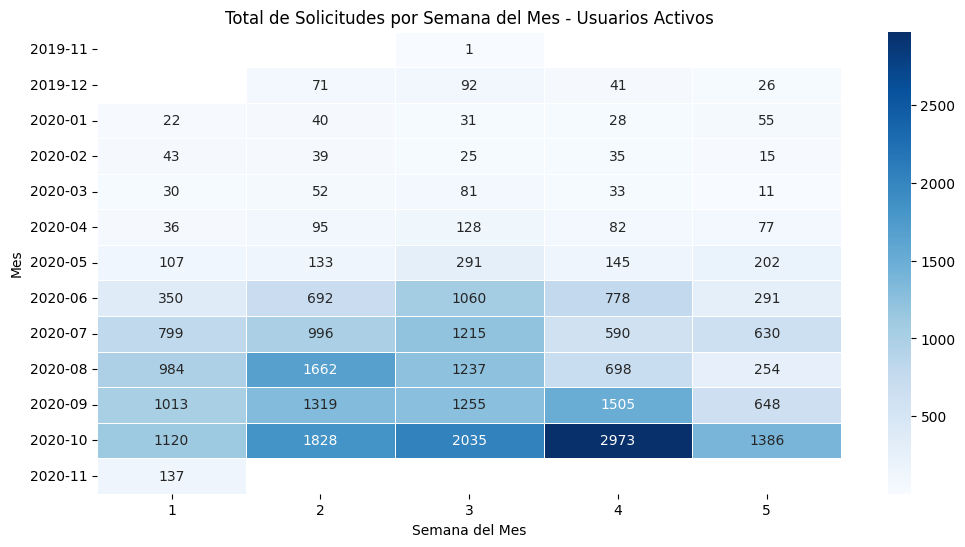

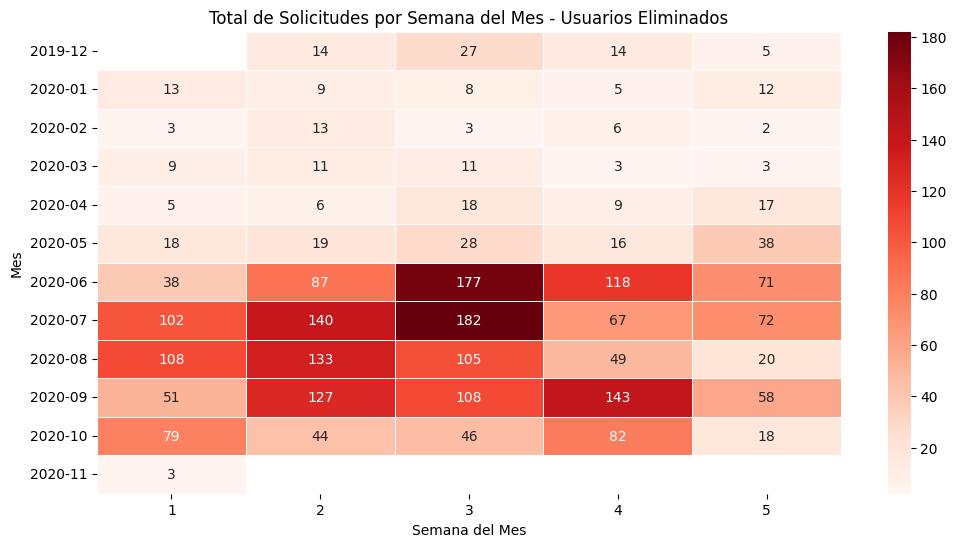

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una nueva columna con la semana dentro del mes
usuarios_activos["semana_mes_solicitud"] = usuarios_activos["created_at"].dt.day // 7 + 1
usuarios_eliminados["semana_mes_solicitud"] = usuarios_eliminados["created_at"].dt.day // 7 + 1

# Crear una tabla de conteo de solicitudes por mes y semana del mes en usuarios activos
solicitudes_por_semana_mes_activos = usuarios_activos.groupby(
    ["mes_solicitud", "semana_mes_solicitud"]
)["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes por mes y semana del mes en usuarios eliminados
solicitudes_por_semana_mes_eliminados = usuarios_eliminados.groupby(
    ["mes_solicitud", "semana_mes_solicitud"]
)["deleted_account_id"].count().unstack()

# Crear la matriz de calor para usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_semana_mes_activos, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)
plt.title("Total de Solicitudes por Semana del Mes - Usuarios Activos")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()

# Crear la matriz de calor para usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(solicitudes_por_semana_mes_eliminados, annot=True, fmt=".0f", cmap="Reds", linewidths=0.5)
plt.title("Total de Solicitudes por Semana del Mes - Usuarios Eliminados")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()


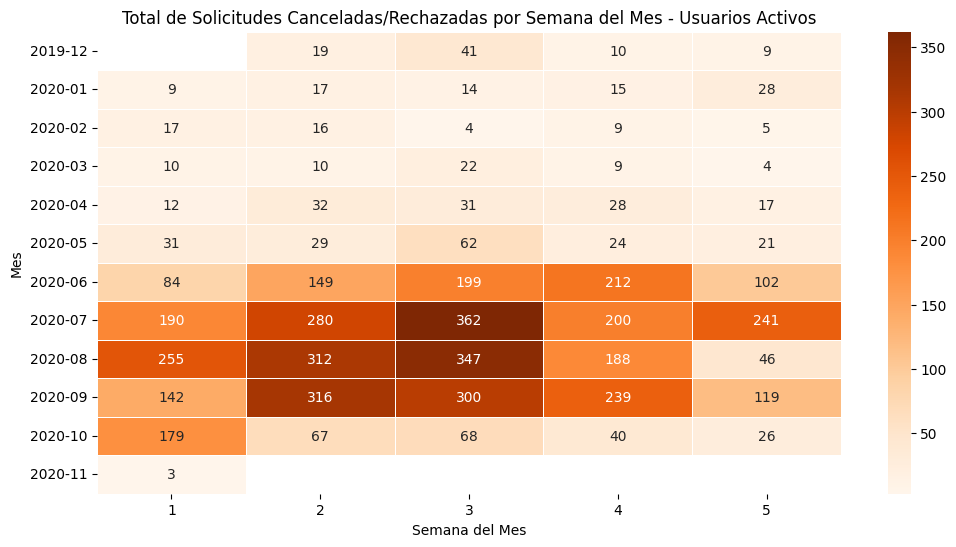

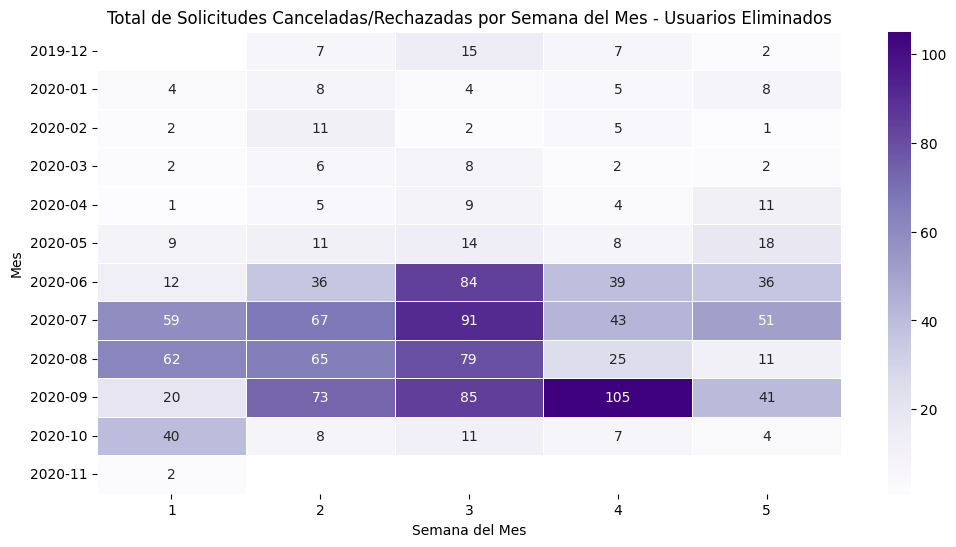

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una tabla de conteo de solicitudes canceladas/rechazadas por mes y semana del mes en usuarios activos
canceladas_rechazadas_por_semana_mes_activos = usuarios_activos[
    usuarios_activos["status"].isin(["cancelled", "rejected"])
].groupby(["mes_solicitud", "semana_mes_solicitud"])["user_id"].count().unstack()

# Crear una tabla de conteo de solicitudes canceladas/rechazadas por mes y semana del mes en usuarios eliminados
canceladas_rechazadas_por_semana_mes_eliminados = usuarios_eliminados[
    usuarios_eliminados["status"].isin(["cancelled", "rejected"])
].groupby(["mes_solicitud", "semana_mes_solicitud"])["deleted_account_id"].count().unstack()

# Crear la matriz de calor para solicitudes canceladas/rechazadas en usuarios activos
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_rechazadas_por_semana_mes_activos, annot=True, fmt=".0f", cmap="Oranges", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas/Rechazadas por Semana del Mes - Usuarios Activos")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()

# Crear la matriz de calor para solicitudes canceladas/rechazadas en usuarios eliminados
plt.figure(figsize=(12, 6))
sns.heatmap(canceladas_rechazadas_por_semana_mes_eliminados, annot=True, fmt=".0f", cmap="Purples", linewidths=0.5)
plt.title("Total de Solicitudes Canceladas/Rechazadas por Semana del Mes - Usuarios Eliminados")
plt.xlabel("Semana del Mes")
plt.ylabel("Mes")
plt.show()


In [13]:
import pandas as pd

# Calcular el tiempo de vida del usuario (días entre primera y última solicitud)
usuarios_activos["tiempo_vida"] = (usuarios_activos.groupby("user_id")["created_at"].transform("max") -
                                   usuarios_activos.groupby("user_id")["created_at"].transform("min")).dt.days

usuarios_eliminados["tiempo_vida"] = (usuarios_eliminados.groupby("deleted_account_id")["created_at"].transform("max") -
                                      usuarios_eliminados.groupby("deleted_account_id")["created_at"].transform("min")).dt.days

# Crear cohortes basados en el tiempo de vida
def clasificar_tiempo_vida(dias):
    if dias < 30:
        return "0-30 días"
    elif dias < 90:
        return "1-3 meses"
    elif dias < 180:
        return "3-6 meses"
    elif dias < 365:
        return "6-12 meses"
    else:
        return "Más de 1 año"

usuarios_activos["cohorte_tiempo_vida"] = usuarios_activos["tiempo_vida"].apply(clasificar_tiempo_vida)
usuarios_eliminados["cohorte_tiempo_vida"] = usuarios_eliminados["tiempo_vida"].apply(clasificar_tiempo_vida)


<ipython-input-14-2b891f134761>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cohort_counts.index, y=cohort_counts.values, palette=color)


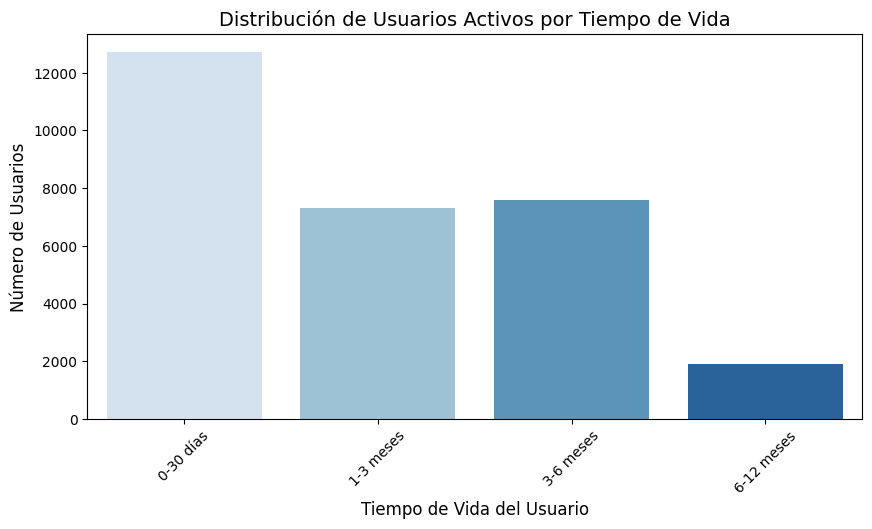

<ipython-input-14-2b891f134761>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cohort_counts.index, y=cohort_counts.values, palette=color)


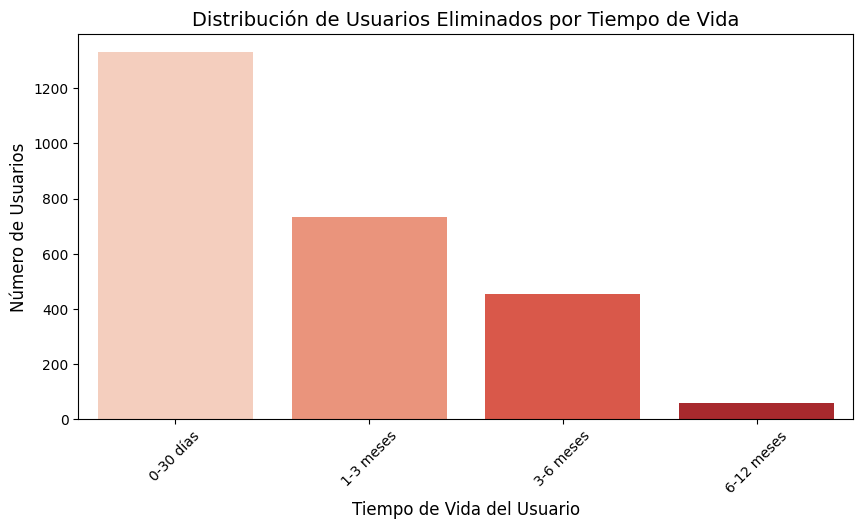

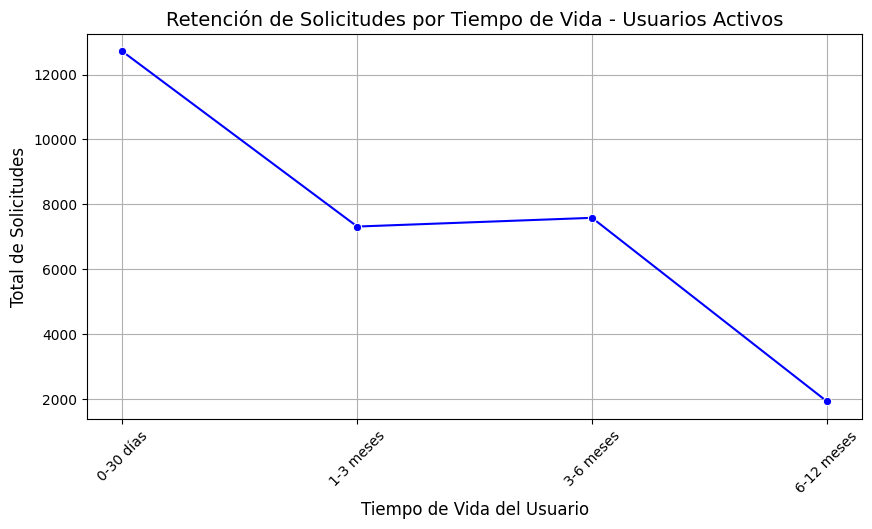

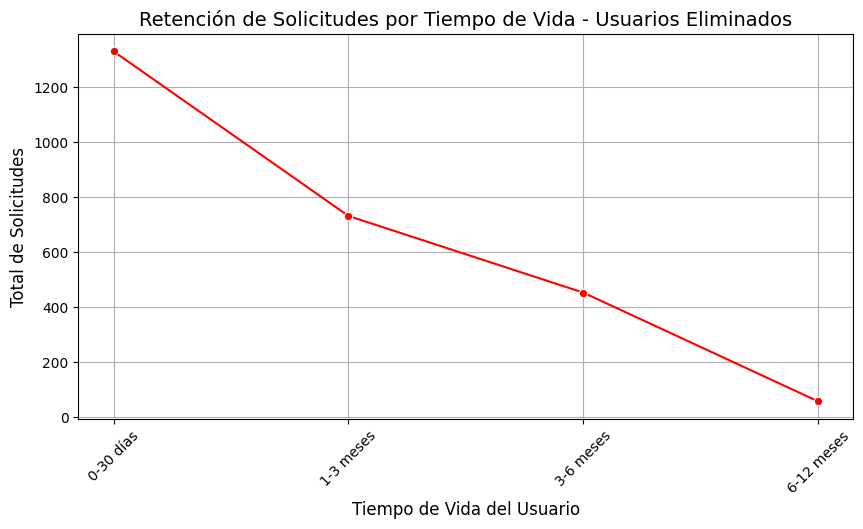

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Función para graficar la distribución de usuarios por tiempo de vida
def graficar_distribucion_tiempo_vida(df, titulo, color):
    cohort_counts = df["cohorte_tiempo_vida"].value_counts().sort_index()

    plt.figure(figsize=(10, 5))
    sns.barplot(x=cohort_counts.index, y=cohort_counts.values, palette=color)
    plt.xlabel("Tiempo de Vida del Usuario", fontsize=12)
    plt.ylabel("Número de Usuarios", fontsize=12)
    plt.title(titulo, fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

# Graficar para usuarios activos y eliminados
graficar_distribucion_tiempo_vida(usuarios_activos, "Distribución de Usuarios Activos por Tiempo de Vida", "Blues")
graficar_distribucion_tiempo_vida(usuarios_eliminados, "Distribución de Usuarios Eliminados por Tiempo de Vida", "Reds")


# 🔹 Función para graficar la retención de solicitudes por cohorte de tiempo de vida
def graficar_retencion_tiempo_vida(df, titulo, color, id_col):
    cohort_retencion = df.groupby("cohorte_tiempo_vida")[id_col].count().reset_index()
    cohort_retencion.columns = ["Cohorte", "Total_Solicitudes"]

    plt.figure(figsize=(10, 5))
    sns.lineplot(x=cohort_retencion["Cohorte"], y=cohort_retencion["Total_Solicitudes"], marker="o", color=color)
    plt.xlabel("Tiempo de Vida del Usuario", fontsize=12)
    plt.ylabel("Total de Solicitudes", fontsize=12)
    plt.title(titulo, fontsize=14)
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

# Graficar retención por tiempo de vida para ambos datasets
graficar_retencion_tiempo_vida(usuarios_activos, "Retención de Solicitudes por Tiempo de Vida - Usuarios Activos", "b", "user_id")
graficar_retencion_tiempo_vida(usuarios_eliminados, "Retención de Solicitudes por Tiempo de Vida - Usuarios Eliminados", "r", "deleted_account_id")
